<a href="https://colab.research.google.com/github/mariiaosinnia/Orbital_City_Lab/blob/main/dead_reckoning_speed_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренування моделі прогнозу швидкості (Dead Reckoning Tracker)

Пайплайн: Kaggle Porto Taxi Trajectory → map matching на граф доріг Порту (osmnx) → тренувальний датасет → XGBoost.

Модель потім використовується сервером для реалістичного "домальовування" руху машини Києвом під час втрати GPS.

## 1. Встановлення залежностей

In [1]:
!pip install osmnx xgboost scikit-learn joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00


## 2. Завантаження датасету Porto Taxi з Kaggle

Потрібен файл `kaggle.json` (Kaggle → Account → Create New API Token). Завантажте його з комп'ютера, коли з'явиться запит нижче.

In [2]:
!pip install kagglehub -q

import kagglehub
import zipfile
import os

# Завантажуємо датасет (версію з crailtap/taxi-trajectory)
print("Завантаження датасету з Kaggle...")
path = kagglehub.dataset_download("crailtap/taxi-trajectory")
print(f"Шлях до завантажених файлів: {path}")

# Розпаковуємо train.csv.zip, якщо він ще не розпакований
zip_path = os.path.join(path, "train.csv.zip")
if os.path.exists(zip_path):
    print("Розпакування train.csv.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Розпаковано в поточну директорію.")
else:
    # Якщо файл вже розпакований у папці kagglehub
    train_path = os.path.join(path, "train.csv")
    if os.path.exists(train_path):
        !cp "{train_path}" .
        print("Файл train.csv скопійовано.")

Завантаження датасету з Kaggle...


100%|██████████| 515M/515M [00:04<00:00, 108MB/s] 

Extracting files...


Шлях до завантажених файлів: /root/.cache/kagglehub/datasets/crailtap/taxi-trajectory/versions/1
Файл train.csv скопійовано.


## 3. Підключення Google Drive (щоб зберегти модель і не втратити прогрес між сесіями)

In [7]:
import os
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 4. Побудова тренувального датасету

Беремо реальні GPS-треки Porto Taxi, рахуємо швидкість між точками (семпл кожні 15с) і прив'язуємо кожну точку до найближчого ребра графа доріг Порту (map matching), щоб дістати фічі: `highway`, `lanes`, `maxspeed`, `is_intersection_ahead`.

`N_TRIPS_SAMPLE` — зменшіть, якщо Colab виконується довго (map matching на nearest_edges — найповільніша частина).

In [8]:
print("Зчитування сирих даних...")
trips_data = []
read_trips = 0

for chunk in pd.read_csv("train.csv", chunksize=CHUNKSIZE, usecols=["POLYLINE", "TIMESTAMP", "MISSING_DATA"]):
    chunk = chunk[chunk["MISSING_DATA"] == False]
    for _, row in chunk.iterrows():
        try:
            points = ast.literal_eval(row["POLYLINE"])
            if len(points) >= 2:
                trips_data.append({"points": points, "timestamp": int(row["TIMESTAMP"])})
                read_trips += 1
        except:
            continue
        if read_trips >= N_TRIPS_SAMPLE:
            break
    if read_trips >= N_TRIPS_SAMPLE:
        break

print(f"Зчитано поїздок: {len(trips_data)}")

# 2. Плоский список усіх точок для масового map matching
all_xs = []
all_ys = []
point_mapping = []  # щоб знайти, яка точка до якої поїздки належить

for trip_idx, trip in enumerate(trips_data):
    for pt_idx, pt in enumerate(trip["points"]):
        all_xs.append(pt[0])
        all_ys.append(pt[1])
        point_mapping.append((trip_idx, pt_idx))

print(f"Запуск масового пошуку найближчих ребер для {len(all_xs)} точок...")

# Виклик функції OSMnx
edges_result = ox.distance.nearest_edges(G, all_xs, all_ys)

# Корекція під різні версії OSMnx (повертає або tuple з двох масивів, або один масив)
if isinstance(edges_result, tuple) and len(edges_result) == 2:
    edges = edges_result[0]
else:
    edges = edges_result

# Безпечне розпакування результату
us = [e[0] for e in edges]
vs = [e[1] for e in edges]
ks = [e[2] for e in edges]

print("Пошук ребер завершено!")

# 3. Збираємо фічі
all_rows = []
# Групуємо результати назад по поїздках
edge_dict = {}
for i, (trip_idx, pt_idx) in enumerate(point_mapping):
    if trip_idx not in edge_dict:
        edge_dict[trip_idx] = {}
    edge_dict[trip_idx][pt_idx] = (us[i], vs[i], ks[i])

for trip_idx, trip in enumerate(trips_data):
    points = trip["points"]
    start_ts = trip["timestamp"]

    for i in range(len(points) - 1):
        lon1, lat1 = points[i]
        lon2, lat2 = points[i + 1]

        dist_m = haversine_m(lon1, lat1, lon2, lat2)
        speed_kmh = (dist_m / 15.0) * 3.6

        if speed_kmh <= 0 or speed_kmh > 130:
            continue

        u, v, k = edge_dict[trip_idx][i]
        try:
            feats = edge_attrs(G, u, v, k)
        except KeyError:
            continue

        ts = start_ts + i * 15
        hour = datetime.datetime.utcfromtimestamp(ts).hour
        is_rush = int(hour in range(7, 10) or hour in range(17, 20))

        all_rows.append({**feats, "hour": hour, "is_rush_hour": is_rush, "speed": speed_kmh})

df = pd.DataFrame(all_rows)
df.to_csv(f"{OUTPUT_DIR}/training_data.csv", index=False)
print(f"Успішно зібрано: {len(df)} рядків")
df.head()

Зчитування сирих даних...
Зчитано поїздок: 8000
Запуск масового пошуку найближчих ребер для 394211 точок...
Пошук ребер завершено!


/tmp/ipykernel_5382/764829682.py:81: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  hour = datetime.datetime.utcfromtimestamp(ts).hour


Успішно зібрано: 378219 рядків


,highway,length,oneway,lanes,maxspeed,is_intersection_ahead,hour,is_rush_hour,speed
0,primary,247.832165,0,2,50.0,1,0,0,3.049338
1,primary,247.832165,0,2,50.0,1,0,0,47.581896
2,primary,394.793488,0,2,50.0,1,0,0,50.606488
3,primary,394.793488,0,2,50.0,1,0,0,39.119151
4,primary,278.662984,0,2,60.0,1,0,0,55.858842


## 5. Тренування XGBoost

[0]	validation_0-rmse:26.86646	validation_1-rmse:27.04102
[50]	validation_0-rmse:21.95237	validation_1-rmse:22.09783
[100]	validation_0-rmse:21.31669	validation_1-rmse:21.48578
[150]	validation_0-rmse:21.05045	validation_1-rmse:21.24467
[200]	validation_0-rmse:20.84075	validation_1-rmse:21.05889
[250]	validation_0-rmse:20.66354	validation_1-rmse:20.90225
[300]	validation_0-rmse:20.51229	validation_1-rmse:20.76678
[350]	validation_0-rmse:20.39487	validation_1-rmse:20.66150
[400]	validation_0-rmse:20.29110	validation_1-rmse:20.57130
[450]	validation_0-rmse:20.20123	validation_1-rmse:20.49867
[500]	validation_0-rmse:20.13684	validation_1-rmse:20.44569
[550]	validation_0-rmse:20.06858	validation_1-rmse:20.39273
[600]	validation_0-rmse:20.00848	validation_1-rmse:20.34623
[650]	validation_0-rmse:19.95615	validation_1-rmse:20.30345
[700]	validation_0-rmse:19.90830	validation_1-rmse:20.26797
[750]	validation_0-rmse:19.86334	validation_1-rmse:20.23400
[800]	validation_0-rmse:19.81595	validation

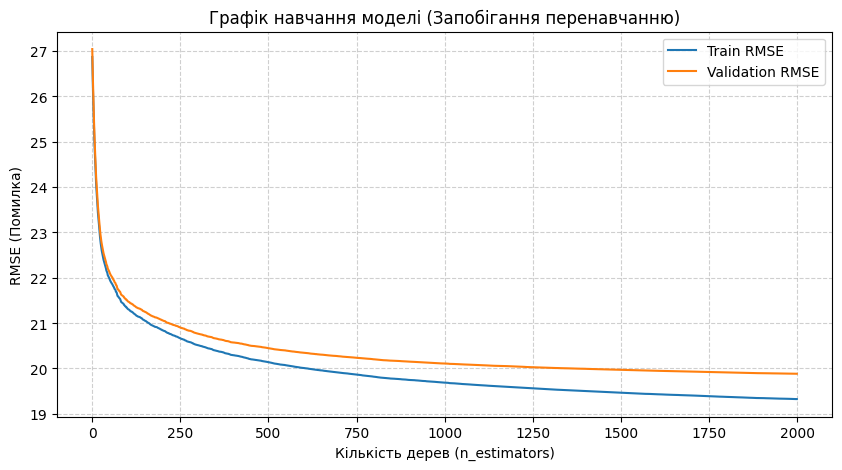


ТОП-10 найважливіших факторів для прогнозу швидкості:
highway_motorway         0.425133
maxspeed                 0.092928
highway_residential      0.076762
highway_primary          0.065247
highway_motorway_link    0.045132
is_intersection_ahead    0.036362
length                   0.033367
highway_tertiary         0.027241
highway_unclassified     0.027186
highway_trunk_link       0.024752
dtype: float32


In [14]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

CATEGORICAL = ["highway"]
NUMERIC = ["length", "oneway", "lanes", "maxspeed", "is_intersection_ahead", "hour", "is_rush_hour"]
TARGET = "speed"

# Побудова фіч
X, encoder = build_features(df)
y = df[TARGET]

# Ділимо на Train, Validation та Test (60% / 20% / 20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

# Налаштовуємо модель із відстеженням метрик на кожному дереві
model = xgb.XGBRegressor(
    n_estimators=2000,        # збільшили кількість дерев
    max_depth=6,             # трохи заглибили для кращої точності
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20 # зупинить тренування, якщо модель почне перенавчатися
)

# Тренуємо та передаємо validation set для моніторингу
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50 # виводити прогрес кожні 50 дерев
)

# 1. Розрахунок розширених метрик на тестових даних
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

# Рахуємо відсоткову помилку (MAPE)
# Рахуємо MAPE лише для точок, де реальна швидкість > 5 км/год, щоб уникнути ділення на 0
non_zero_mask = y_test > 5
mape = np.mean(np.abs((y_test[non_zero_mask] - preds[non_zero_mask]) / y_test[non_zero_mask])) * 100

# Альтернатива: Симетричний MAPE (за бажанням)
# smape = np.mean(2.0 * np.abs(preds - y_test) / (np.abs(preds) + np.abs(y_test))) * 100
print("\n" + "="*30 + "\nМЕТРИКИ МОДЕЛІ ДЛЯ ЖУРІ:\n" + "="*30)
print(f"MAE (Середня абсолютна помилка):  {mae:.2f} км/год  <-- в середньому помиляємось на стільки")
print(f"RMSE (Корінь з середньоквадр.):   {rmse:.2f} км/год  <-- чутлива до великих викидів помилка")
print(f"MAPE (Середня відсоткова помилка): {mape:.2f}%       <-- відхилення у відсотках від реальності")
print(f"R² (Коефіцієнт детермінації):      {r2:.3f}       <-- на скільки якісно модель описує дані (макс 1)")

# 2. Побудова графіка навчання (Learning Curves) для презентації
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation RMSE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylabel('RMSE (Помилка)')
plt.xlabel('Кількість дерев (n_estimators)')
plt.title('Графік навчання моделі (Запобігання перенавчанню)')
plt.show()

# 3. Важливість фіч
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nТОП-10 найважливіших факторів для прогнозу швидкості:")
print(importances.head(10))

## 6. Збереження моделі на Google Drive

In [10]:
joblib.dump(
    {"model": model, "encoder": encoder, "numeric_cols": NUMERIC, "categorical_cols": CATEGORICAL},
    f"{OUTPUT_DIR}/speed_model.joblib",
)
print(f"Модель збережено у {OUTPUT_DIR}/speed_model.joblib")

Модель збережено у ./output/speed_model.joblib


## 7. Приклад використання (на сервері)

In [11]:
def predict_speed(model, encoder, edge_features: dict) -> float:
    df = pd.DataFrame([edge_features])
    X, _ = build_features(df, encoder=encoder)
    return float(model.predict(X)[0])

example = {
    "highway": "residential",
    "length": 80,
    "oneway": 0,
    "lanes": 1,
    "maxspeed": 30,
    "is_intersection_ahead": 1,
    "hour": 18,
    "is_rush_hour": 1,
}
predict_speed(model, encoder, example)

13.341678619384766

In [15]:
import pickle

model_artifact = {
    "model": model,
    "encoder": encoder,
    "numeric_cols": NUMERIC,
    "categorical_cols": CATEGORICAL
}

output_path = f"{OUTPUT_DIR}/speed_model.pkl"
with open(output_path, "wb") as f:
    pickle.dump(model_artifact, f)

print(f"Модель успішно збережено через pickle: {output_path}")

Модель успішно збережено через pickle: ./output/speed_model.pkl
